# K-Means Clustering Demonstration In Python
#### Using Retail Data

## Background 
This dataset contains customer-level transactional and behavioral information from a retail business operating across multiple regions. Each record represents a unique customer, capturing their spending value, purchase frequency, brand diversity, and growth trend over a specific period. The data is used for clustering to identify distinct customer segments with similar purchasing behaviors. These segments help businesses design targeted marketing and customer retention strategies.

## Objective
To apply **K-Means clustering** on retailers data for customer segmentation. This notebook explains each step in detail, includes comments for clarity, and suggests alternative methods where appropriate.



## Data Description
The dataset contains retailer-level numeric variables used to identify homogeneous groups based on purchasing and behavioral patterns.


| Column Name | Description |
|------------|-------------|
| Custid | Unique customer identifier |
| nsv | Net Sales Value generated by the customer (total monetary value of purchases) |
| n_brands | Number of distinct brands purchased by the customer |
| n_bills | Total number of bills / transactions made by the customer |
| growth | Percentage growth or decline in customer spending compared to a previous period |
| region | Geographical region where the customer primarily shops |


### Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Optional: for better plots
plt.rcParams['figure.figsize'] = (8,5)

### Import Data

In [2]:
# Load the dataset
df = pd.read_csv('RETAILERS DATA.csv')
df.head()

,Custid,nsv,n_brands,n_bills,growth,region
0,1001,2119456,7,14,-1.79,Mumbai
1,1002,1460163,12,42,-1.73,Mumbai
2,1003,147976,4,6,2.81,Mumbai
3,1004,1350474,13,30,-0.99,Delhi
4,1005,1414461,15,29,13.56,Delhi


In [3]:
# Check data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1158 entries, 0 to 1157
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Custid    1158 non-null   int64  
 1   nsv       1158 non-null   int64  
 2   n_brands  1158 non-null   int64  
 3   n_bills   1158 non-null   int64  
 4   growth    1158 non-null   float64
 5   region    1158 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 54.4+ KB


In [4]:
# Summary statistics
df.describe()

,Custid,nsv,n_brands,n_bills,growth
count,1158.000000,1.158000e+03,1158.000000,1158.000000,1158.000000
mean,1579.500000,9.583795e+05,11.735751,18.966321,4.741762
std,334.430112,8.658664e+05,8.305278,18.281665,4.642513
min,1001.000000,1.181290e+05,2.000000,3.000000,-3.970000
25%,1290.250000,2.566340e+05,6.000000,6.000000,2.282500
50%,1579.500000,5.022935e+05,9.000000,12.000000,4.530000
75%,1868.750000,1.623510e+06,15.000000,26.000000,5.727500
max,2158.000000,4.355244e+06,56.000000,133.000000,27.540000


### Data Preprocessing
####  Why Scaling is Required?
K-Means uses **Euclidean distance**. Variables with larger scales dominate distance calculations. Hence, standardization is mandatory.

**Method Used:** Z-score standardization

**Alternative:** MinMaxScaler (useful when bounds are known)

---

**Note:**

K-Means requires **only numeric variables**


In [5]:
#drop customer id and region
cluster_data = df.drop(columns = ['Custid','region'],axis = 1)
# Standardize variables
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

scaled_data

array([[ 1.3415212 , -0.57045618, -0.27177323, -1.40755324],
       [ 0.57976648,  0.03183071,  1.2604777 , -1.39462362],
       [-0.93634948, -0.93182832, -0.70955921, -0.41628239],
       ...,
       [ 1.04097324,  0.03183071,  0.43962899, -1.08862262],
       [-0.76570907, -0.57045618, -0.76428245, -0.19647886],
       [ 1.55237455,  2.8023504 ,  2.13604966,  1.37016007]])

### Perform K-Means Clustering


In [6]:
# Apply K-Means with predefined K
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Attach cluster labels to original data
df['Cluster'] = clusters
df.head()

,Custid,nsv,n_brands,n_bills,growth,region,Cluster
0,1001,2119456,7,14,-1.79,Mumbai,2
1,1002,1460163,12,42,-1.73,Mumbai,2
2,1003,147976,4,6,2.81,Mumbai,0
3,1004,1350474,13,30,-0.99,Delhi,2
4,1005,1414461,15,29,13.56,Delhi,1


### Cluster Profiling
We interpret clusters using **original (unscaled) variables**, which is crucial for business understanding.

In [7]:
# Cluster-wise summary

# numeric columns only (except Cluster)
num_cols = ["nsv", "n_brands", "n_bills", "growth"]

cluster_profile = df.groupby("Cluster")[num_cols].mean()
cluster_profile["count"] = df.groupby("Cluster").size()

print(cluster_profile)

                  nsv   n_brands    n_bills     growth  count
Cluster                                                      
0        3.455812e+05   8.053977   8.286932   3.440781    704
1        1.875311e+06  24.238095  48.619048  12.275762    210
2        1.937290e+06  11.598361  24.258197   2.011230    244


### Visualizing Clusters

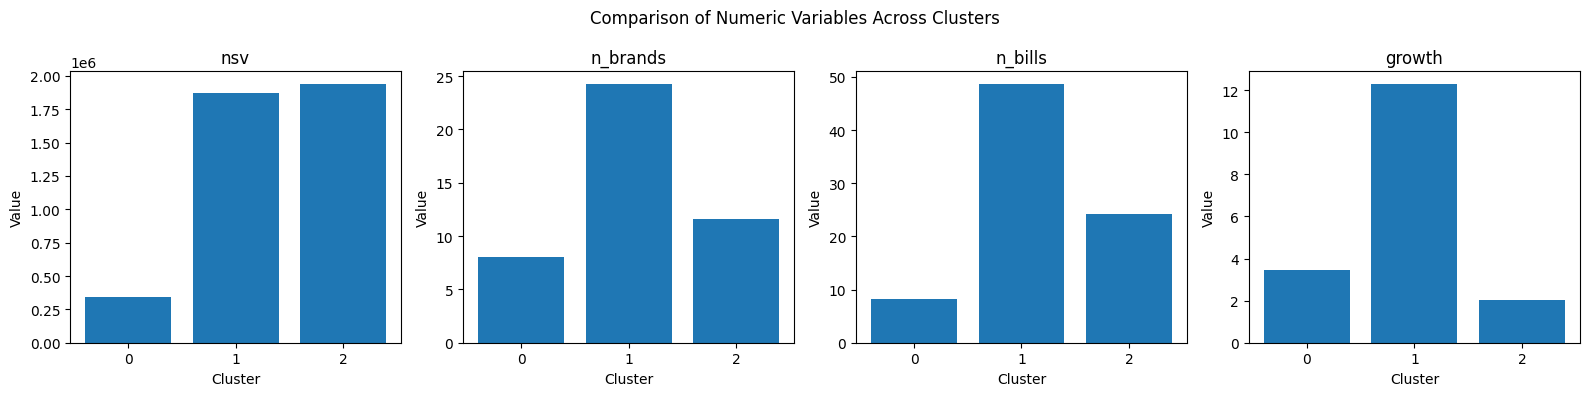

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, cluster_profile.columns):
    ax.bar(cluster_profile.index, cluster_profile[col])
    ax.set_title(col)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Value")
    ax.set_xticks(cluster_profile.index)

plt.suptitle("Comparison of Numeric Variables Across Clusters")
plt.tight_layout()
plt.show()


### Interpretation 
- Cluster 1 shows high average values across key metrics, indicating high-value / platinum retailers with strong sales, higher engagement, and positive growth.

- Cluster 0 has low average values, representing low-performing retailers with lower sales contribution and limited engagement.

### Elbow Method for Optimal K
The Elbow Method evaluates **Within-Cluster Sum of Squares (WCSS)**.

**Rule:** Choose K where marginal reduction in WCSS drops sharply.

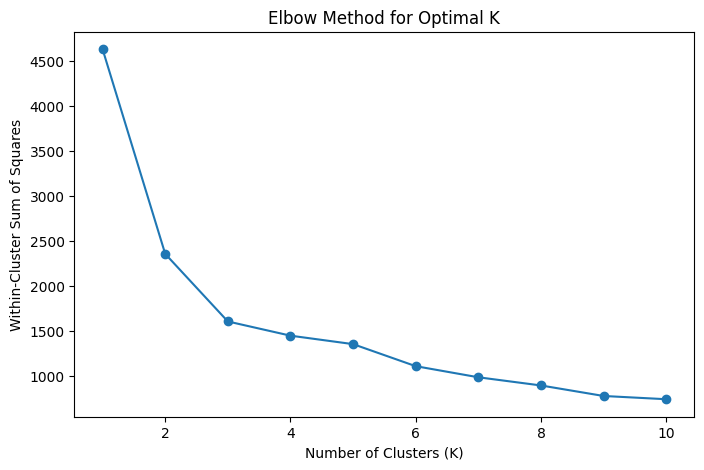

In [9]:
# Elbow Method implementation
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

# Plot
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.title('Elbow Method for Optimal K')
plt.show()

### Interpretation
The bend in the curve suggests **K = 3 or 4** as a reasonable solution.

---

### One can further explore a clustering solution with k = 4 and compare the resulting clusters with the current solution